# Sentiment Timeline Analysis

This notebook presents the sentiment timeline analysis


In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import sys

In [2]:
cwd = Path.cwd().resolve()
root_dir = next((path for path in [cwd, *cwd.parents] if (path / "src").exists() and (path / "data" / "rmp_ucsd_reviews.csv").exists()), None)
if root_dir is None:
    raise FileNotFoundError("Could not find the project root from the current notebook working directory.")
data_dir = root_dir / "data" / "rmp_ucsd_reviews.csv"
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))
df = pd.read_csv(data_dir)



In [3]:
COLUMNS_TO_KEEP = [
    "date",
    "class",
    "qualityRating",
    "difficultyRatingRounded",
    "grade",
    "comment",
]
df = df[COLUMNS_TO_KEEP].copy()
valid_course_pattern = r"^[A-Z]{3,}[0-9]+[A-Z]?$"
df = df[df["class"].str.match(valid_course_pattern, na=False)].copy()
df

,date,class,qualityRating,difficultyRatingRounded,grade,comment
1,2014-05-10 14:33:50 +0000 UTC,POLI142A,4,1,NaN,He was a great professor. I loved his lecture ...
2,2013-07-04 17:27:33 +0000 UTC,POLI142A,2,1,NaN,Going to his lectures was pointless. They had ...
3,2013-06-09 04:32:47 +0000 UTC,POLI142A,2,3,NaN,He knows his stuff. But the problem is his a s...
4,2009-06-08 14:11:13 +0000 UTC,INTL190,5,3,NaN,This guy know his stuff. Just come to class pr...
5,2019-05-29 21:54:59 +0000 UTC,POLI104A,3,5,Not sure yet,"Professor Litman has a distinguished resume, b..."
...,...,...,...,...,...,...
38691,2025-03-25 04:59:52 +0000 UTC,PHYS2B,4,4,Not sure yet,Just go to the lectures and actually do the ho...
38692,2025-03-10 22:38:30 +0000 UTC,PHYS2B,5,2,A,Although sometimes his explanations can be vag...
38693,2025-02-10 07:23:16 +0000 UTC,PHYS2B,2,5,Not sure yet,"His lectures are really unclear, he doesn't ex..."
38694,2025-02-02 21:46:01 +0000 UTC,PHYS2A,3,4,B,Tough quizzes that require deep conceptual kno...


In [4]:
df = df.dropna().copy()
df = df.rename(columns={
    "qualityRating": "quality",
    "clarityRatingRounded": "clarity",
    "difficultyRatingRounded": "difficulty",
})
df

,date,class,quality,difficulty,grade,comment
5,2019-05-29 21:54:59 +0000 UTC,POLI104A,3,5,Not sure yet,"Professor Litman has a distinguished resume, b..."
7,2014-03-17 03:16:47 +0000 UTC,MATH194,5,3,A,I love this class and Prof Puha. The material ...
16,2025-09-30 01:13:55 +0000 UTC,MGT175,2,3,B+,"Was not a fan of the 3 hour lectures, and Prof..."
17,2025-03-30 15:24:41 +0000 UTC,MGT175,4,2,A,Attendance is a grade but for us his midterm w...
18,2023-11-17 01:06:28 +0000 UTC,MGT175,2,4,Not sure yet,Very knowledgeable and accomplished individual...
...,...,...,...,...,...,...
38691,2025-03-25 04:59:52 +0000 UTC,PHYS2B,4,4,Not sure yet,Just go to the lectures and actually do the ho...
38692,2025-03-10 22:38:30 +0000 UTC,PHYS2B,5,2,A,Although sometimes his explanations can be vag...
38693,2025-02-10 07:23:16 +0000 UTC,PHYS2B,2,5,Not sure yet,"His lectures are really unclear, he doesn't ex..."
38694,2025-02-02 21:46:01 +0000 UTC,PHYS2A,3,4,B,Tough quizzes that require deep conceptual kno...


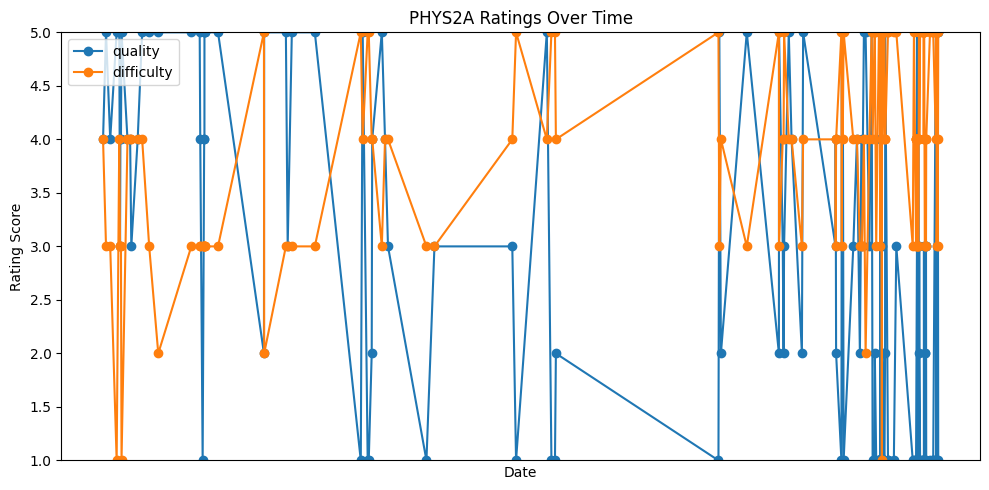

In [5]:
from src.sentiment import normalize_dates, filter_courses, plot_course_ratings

course = "PHYS2A"

df_clean = normalize_dates(df=df)
df_filtered = filter_courses(df=df_clean,
                             course=course,
                             start_date=pd.Timestamp("2016-01-01"),
                             end_date=pd.Timestamp("2026-12-31"))
fig, ax = plot_course_ratings(df=df_filtered, course=course)
plt.show()

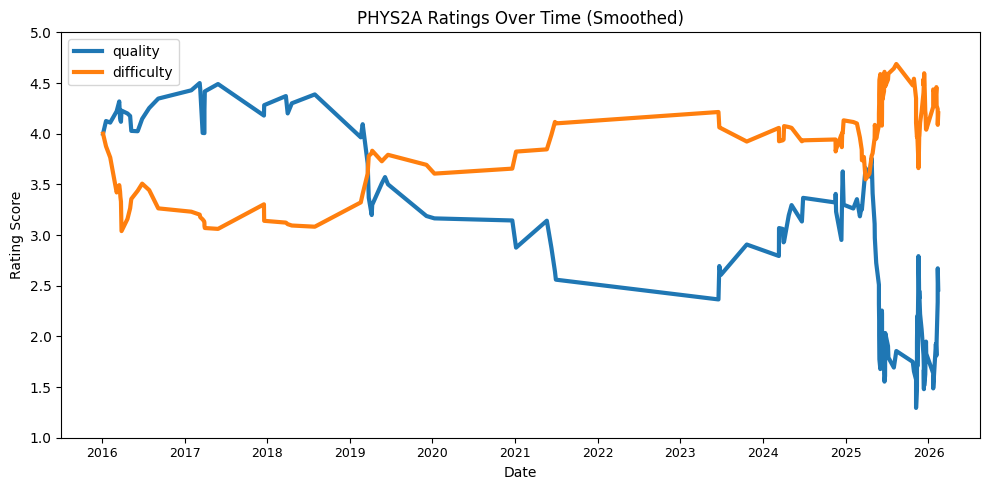

In [6]:
from src.sentiment import smooth_ratings, plot_smoothed_ratings

df_smoothed = smooth_ratings(df_filtered)

fig, ax = plot_smoothed_ratings(df_smoothed, course)
plt.show()

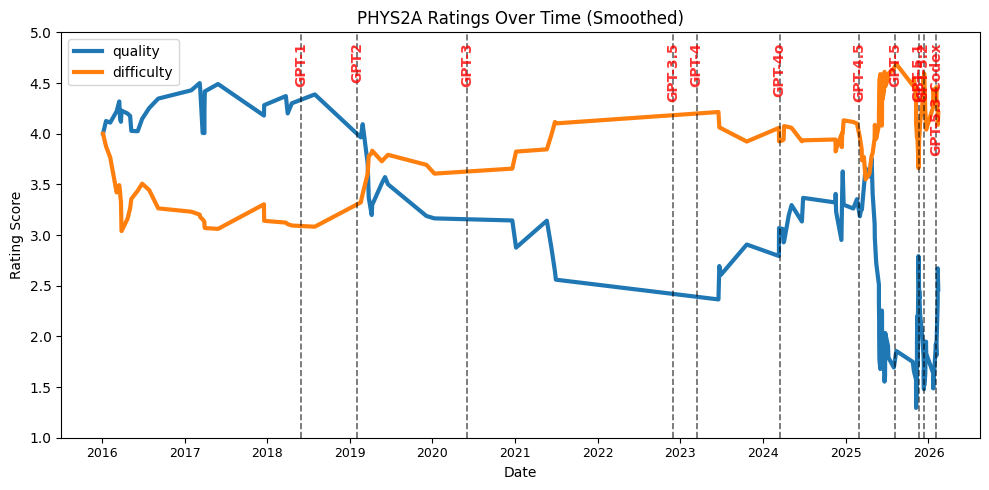

In [7]:
from src.sentiment import load_releases, overlay_releases

releases_df = load_releases(root_dir / "data" / "chatgpt_model_updates.csv")

fig, ax = plot_smoothed_ratings(df_smoothed, course)
overlay_releases(ax, releases_df)

plt.show()

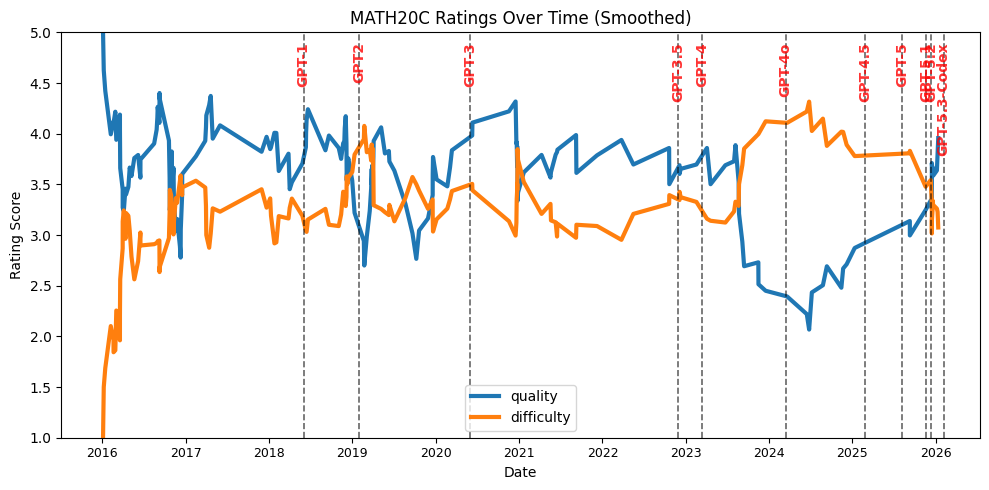

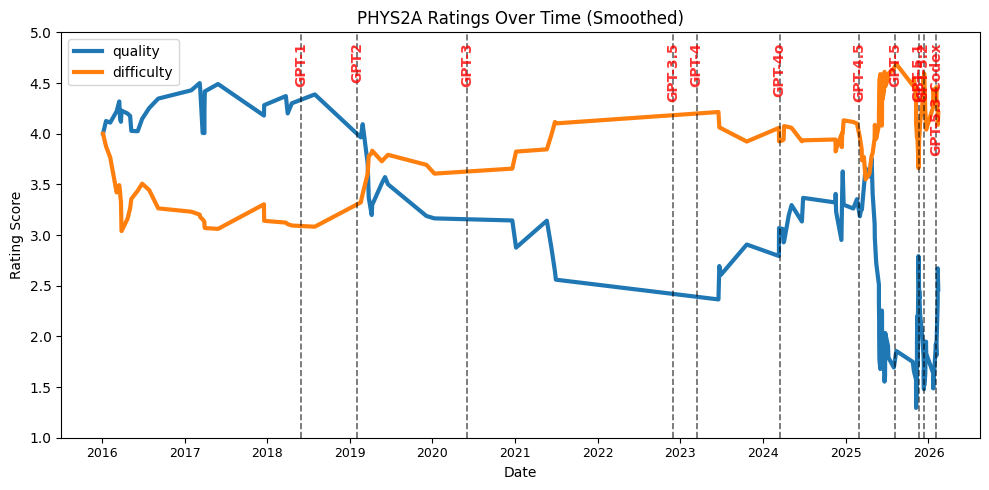

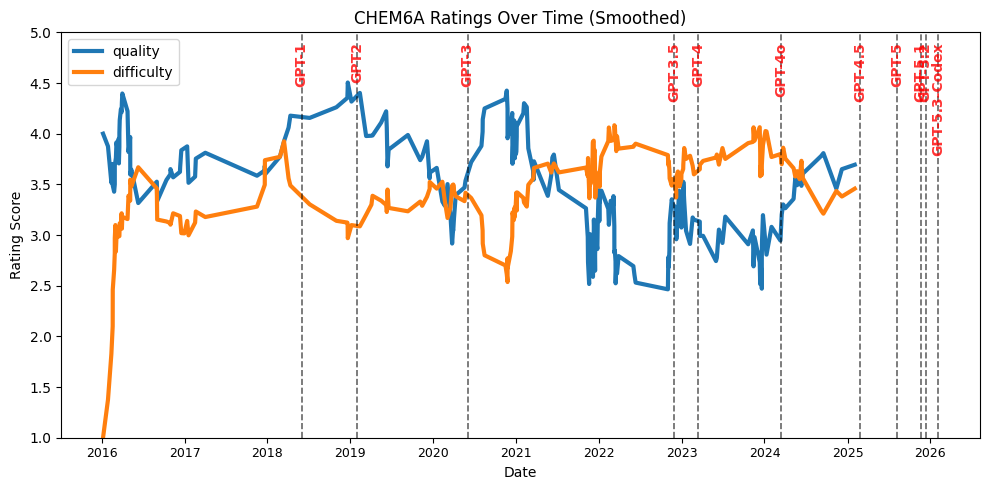

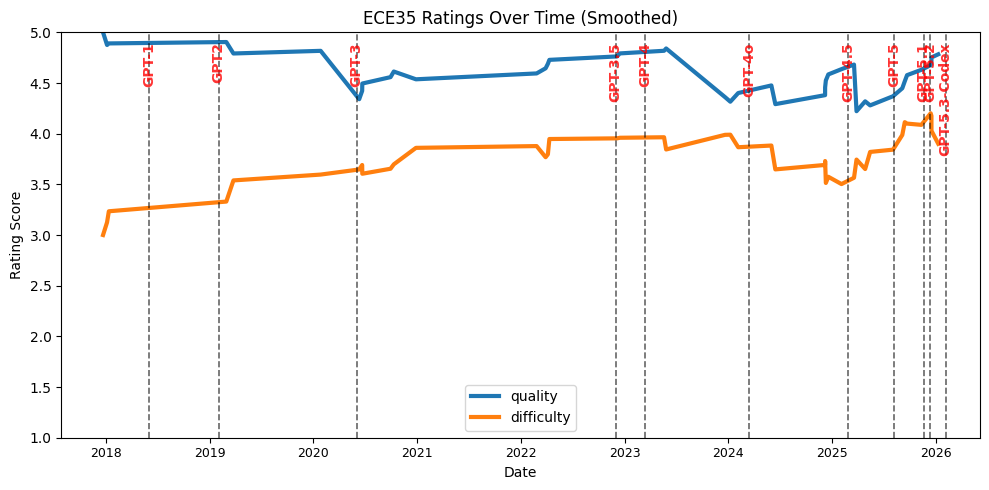

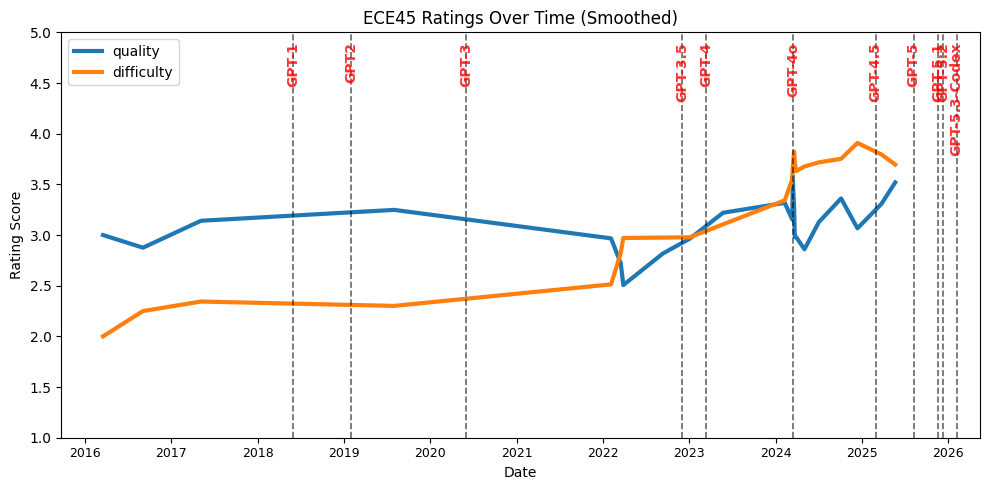

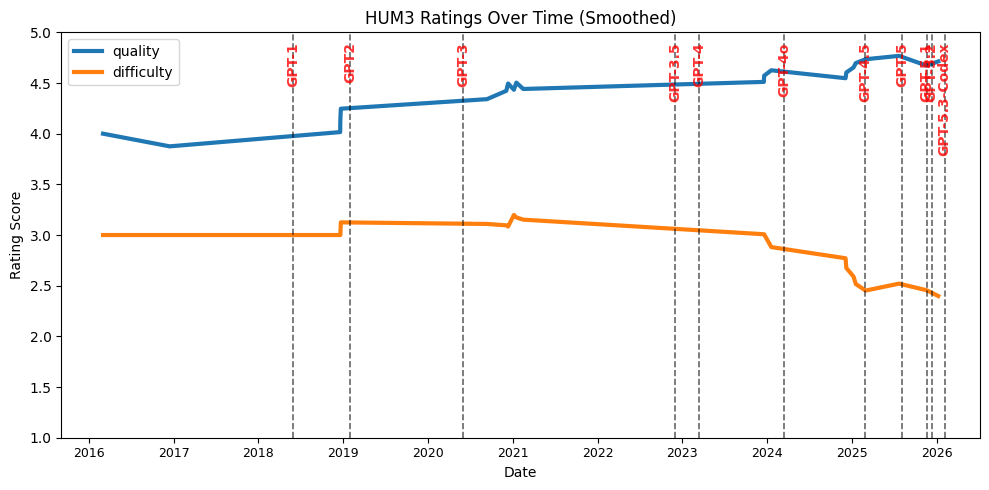

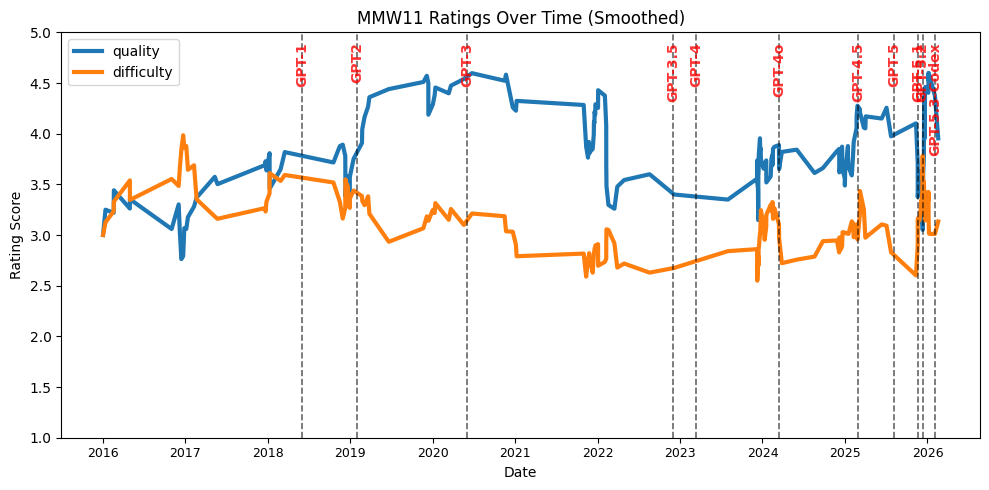

In [8]:
course_list = ["MATH20C", "PHYS2A", "CHEM6A", "ECE35", "ECE45", "HUM3", "MMW11"]

for course in course_list:
    df_filtered = filter_courses(df=df_clean,
                             course=course,
                             start_date=pd.Timestamp("2016-01-01"),
                             end_date=pd.Timestamp("2026-12-31"))
    df_smoothed = smooth_ratings(df_filtered)
    fig, ax = plot_smoothed_ratings(df_smoothed, course)
    overlay_releases(ax, releases_df)

plt.show()
